In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import re, collections
import seaborn as sns

ACCENT, GREY, LIGHT = "#1F6F8B", "#9AA8B3", "#C9D6DC"
PAIR = [ACCENT, GREY]
sns.set_theme(style="whitegrid", context="notebook", rc={"figure.figsize": (8, 4.2),
              "axes.spines.top": False, "axes.spines.right": False})

def hbar(data, y, x, ax, fmt="{:,.0f}", color=ACCENT):
    """Horizontal seaborn bar chart in the frame's order, with value labels."""
    sns.barplot(data=data, y=y, x=x, ax=ax, color=color, orient="h", order=list(data[y]))
    ax.bar_label(ax.containers[0], labels=[fmt.format(v) for v in data[x]], padding=3, fontsize=8)
    ax.set_xlim(0, data[x].max() * 1.18)
    ax.set_ylabel("")

def paired_share(data, cat, cols, names, ax):
    """Two percentage columns side by side per category (e.g. % repos vs % files)."""
    long = data.melt(id_vars=cat, value_vars=cols, var_name="measure", value_name="pct")
    long["measure"] = long.measure.map(dict(zip(cols, names)))
    sns.barplot(data=long, x=cat, y="pct", hue="measure", palette=PAIR, ax=ax, order=list(data[cat]))
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.1f", fontsize=8)
    ax.set_ylabel("%"); ax.legend(title="")

from pathlib import Path

def _abs_parquet(rel):
    """Resolve a path relative to src/notebooks and return the absolute parquet path."""
    here = Path.cwd().resolve()
    data = None
    for candidate in (here, *here.parents):
        if (candidate / 'src' / 'data').is_dir() and (candidate / 'src' / 'notebooks').is_dir():
            data = candidate / 'src' / 'data'
            break
        if candidate.name == 'notebooks' and (candidate.parent / 'data').is_dir():
            data = (candidate.parent / 'data').resolve()
            break
    if data is None:
        raise FileNotFoundError(f'Could not locate src/data from {here}')
    path = (data / rel.removeprefix('../data/')).resolve()
    matches = list(path.parent.glob(path.name)) if '*' in path.name else ([path] if path.is_file() else [])
    if not matches:
        raise FileNotFoundError(path)
    return str(path)

repos_path = _abs_parquet('../data/gitskills_data/data/repos/*.parquet')
artifacts_path = _abs_parquet('../data/gitskills_data/data/artifacts/*.parquet')
artifact_siblings_path = _abs_parquet('../data/gitskills_data/data/artifact_siblings/*.parquet')
mining_runs_path = _abs_parquet('../data/gitskills_data/data/mining_runs/*.parquet')
skill_features_path = _abs_parquet('../data/generated_data/skill_features.parquet')
file_agents_path = _abs_parquet('../data/generated_data/file_agents.parquet')

con = duckdb.connect(database=':memory:')
con.execute(f"""
CREATE VIEW artifacts AS 
SELECT * FROM '{artifacts_path}'
""")

## Authorship signals

Commit history, bot authors, AI co-author trailers, revisions, and how AI-trailer skills differ.


In [23]:
authorship = con.execute(f"""
    SELECT SUM(history_fetched = 1) AS with_history,
       COUNT(*)                 AS distinct_skills,
       ROUND(100.0 * SUM(history_fetched = 1) / COUNT(*), 1) AS pct
    FROM artifacts WHERE dedup_primary = 1
""").df().astype(int)
authorship

,with_history,distinct_skills,pct
0,458137,1877981,24


#### Coverage: commit history

Only about a quarter of distinct skills have commit history: 458,548 of 1,877,981 (24.4%) in the full dataset.
Commit-based signals (AI trailers, author type, revisions) therefore cover at most ~24% of skills; the rest rely on text and repository features alone.
History reflects the representative file's repository and current path only.

In [24]:
user_commits = con.execute(f"""
    SELECT first_commit_author_type, last_commit_author_type, COUNT(*) AS skills
    FROM artifacts WHERE dedup_primary = 1 AND history_fetched = 1
    GROUP BY 1, 2 ORDER BY skills DESC
""").df()
user_commits

,first_commit_author_type,last_commit_author_type,skills
0,User,User,384780
1,,,58488
2,Bot,Bot,4299
3,User,,4274
4,,User,4182
5,User,Bot,1541
6,Bot,User,299
7,Organization,Organization,149
8,,Bot,78
9,Bot,,32


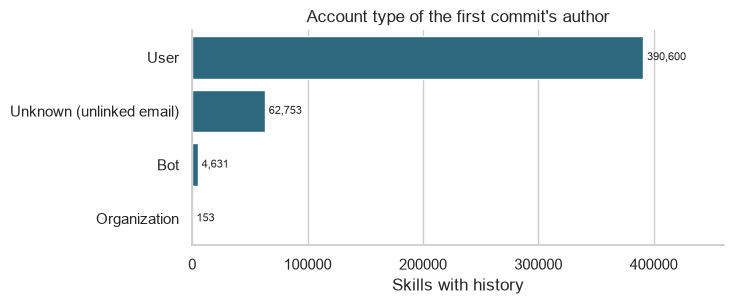

In [25]:
kind = (user_commits.assign(type=user_commits.first_commit_author_type.replace(
            {"": "Unknown (unlinked email)", "Mannequin": "Unknown (unlinked email)",
             "ProgrammaticAccessBot": "Bot"}))
        .groupby("type", as_index=False).skills.sum().sort_values("skills", ascending=False))
fig, ax = plt.subplots(figsize=(7.5, 3.2))
hbar(kind, "type", "skills", ax)
ax.set_xlabel("Skills with history"); ax.set_title("Account type of the first commit's author")
plt.tight_layout(); plt.show()

In [26]:
bot_commits = con.execute(f"""
    SELECT first_commit_author, COUNT(*) AS skills
    FROM read_parquet('{artifacts_path}') WHERE dedup_primary = 1 AND history_fetched = 1
        AND first_commit_author_type = 'Bot'
    GROUP BY 1 ORDER BY skills DESC;
""").df()
bot_commits

,first_commit_author,skills
0,github-actions[bot],2997
1,Copilot,714
2,ecc-tools[bot],201
3,clawdhub[bot],107
4,devin-ai-integration[bot],81
...,...,...
135,mewbo-ai[bot],1
136,oz-for-oss[bot],1
137,capy-ai[bot],1
138,ls-cursor-team-plugin-release[bot],1


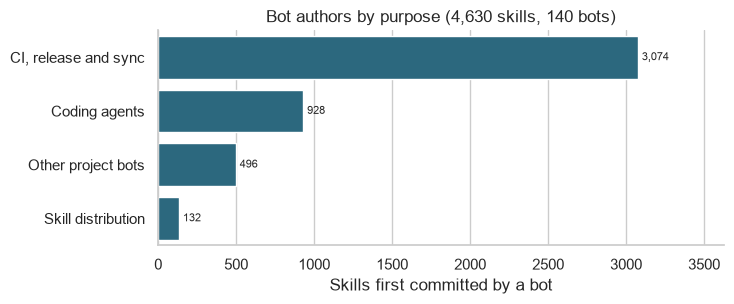

In [27]:
AGENTS  = r"copilot|devin|jules|opencode|^claude|lovable|kilo-code|codex|factory-droid|amazon-q|codegen|capy-ai|warp-dev|cursor"
DISTRIB = r"clawdhub|txtskills|skill"
def bot_group(name):
    n = name.lower()
    if n in ("github-actions[bot]", "dependabot[bot]", "renovate[bot]") or "release" in n or "sync" in n:
        return "CI, release and sync"
    if re.search(AGENTS, n):  return "Coding agents"
    if re.search(DISTRIB, n): return "Skill distribution"
    return "Other project bots"
groups = (bot_commits.assign(group=bot_commits.first_commit_author.map(bot_group))
          .groupby("group", as_index=False).skills.sum().sort_values("skills", ascending=False))
fig, ax = plt.subplots(figsize=(7.5, 3.2))
hbar(groups, "group", "skills", ax)
ax.set_xlabel("Skills first committed by a bot")
ax.set_title(f"Bot authors by purpose ({groups.skills.sum():,} skills, {len(bot_commits)} bots)")
plt.tight_layout(); plt.show()

## Bot authors (first commit)

4,630 skills were first committed by a bot, across 140 distinct bot accounts.
The distribution is highly concentrated: `github-actions[bot]` alone accounts
for 2,997 (65%), reflecting CI workflows that generate, sync or publish skill
files rather than write them. About 20% (~926) come from coding agents
committing under their own identity: `Copilot` (714), Devin (81), Google Jules
(48), and smaller counts for opencode, Claude, Lovable, Kilo Code and Codex.
These are the strongest agent-authorship evidence in the dataset, stronger than
co-author trailers, because the agent is the commit author. A further group are
skill-distribution bots (e.g. `clawdhub[bot]`, 107) that publish or mirror
skills. The long tail (100+ bots with ≤5 skills each) is mostly
project-specific release, sync and agent-harness automation.

For the classifier, treat these groups differently:

- Coding agents are a direct "agent-authored" signal for the commit.
- CI and distribution bots mean the file was moved or published by automation; the real author is unknown. Treat them like bulk installs.

In [28]:
trailers = con.execute(f"""
    SELECT CASE
        WHEN lower(first_commit_message) LIKE '%co-authored-by:%claude%'
        OR lower(first_commit_message) LIKE '%co-authored-by:%anthropic%' THEN 'Claude'
        WHEN lower(first_commit_message) LIKE '%co-authored-by:%cursor%'    THEN 'Cursor'
        WHEN lower(first_commit_message) LIKE '%co-authored-by:%copilot%'   THEN 'Copilot'
        WHEN lower(first_commit_message) LIKE '%co-authored-by:%codex%'
        OR lower(first_commit_message) LIKE '%co-authored-by:%openai%'    THEN 'Codex/OpenAI'
        WHEN lower(first_commit_message) LIKE '%co-authored-by:%gemini%'    THEN 'Gemini'
        WHEN lower(first_commit_message) LIKE '%co-authored-by:%'           THEN 'Other co-author'
        ELSE 'No trailer'
        END AS trailer,
    COUNT(*) AS skills,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM read_parquet('{artifacts_path}') WHERE dedup_primary = 1 AND history_fetched = 1
    GROUP BY trailer ORDER BY skills DESC;
""").df()
trailers

,trailer,skills,pct
0,No trailer,313829,68.5
1,Claude,132010,28.8
2,Other co-author,5638,1.2
3,Cursor,3602,0.8
4,Copilot,2719,0.6
5,Codex/OpenAI,303,0.1
6,Gemini,36,0.0


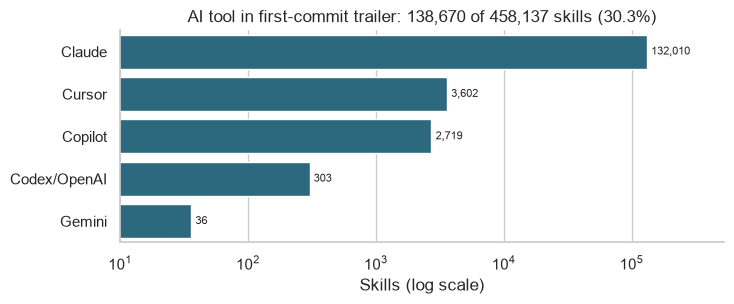

In [29]:
ai = trailers[~trailers.trailer.isin(["No trailer", "Other co-author"])]
ai_total, base = ai.skills.sum(), trailers.skills.sum()
fig, ax = plt.subplots(figsize=(7.5, 3.2))
sns.barplot(data=ai, y="trailer", x="skills", orient="h", color=ACCENT, order=list(ai.trailer), ax=ax)
ax.bar_label(ax.containers[0], labels=[f"{v:,}" for v in ai.skills], padding=3, fontsize=8)
ax.set_xscale("log"); ax.set_xlim(10, ai.skills.max() * 4)
ax.set_xlabel("Skills (log scale)"); ax.set_ylabel("")
ax.set_title(f"AI tool in first-commit trailer: {ai_total:,} of {base:,} skills ({100*ai_total/base:.1f}%)")
plt.tight_layout()
plt.show()

## AI co-author trailers (first commit)

30.3% of skills with history (138,670 of 458,137) have an AI tool named in a
`Co-authored-by` trailer on their first commit. Claude dominates with 132,010
(95.2% of AI trailers), followed by Cursor (3,602), Copilot (2,719),
Codex/OpenAI (303) and Gemini (36). A further 5,638 (1.2%) name a co-author
that isn't a known AI tool, mostly human collaborators. The trailer is a
positive-only signal: its presence indicates the commit was made with an AI
tool, but its absence (68.5%) does not indicate human authorship, since many
tools and users don't add it. It also describes the commit, not necessarily
the writing of the skill, as bulk installs show.

A trailer is a key–value line at the end of a git commit message, after a blank line. Git and GitHub treat these lines as structured metadata rather than ordinary text.

A commit made with Claude Code typically looks like this:

```
feat: add code-review skill

Adds a skill that checks PRs for style and test coverage.

Co-authored-by: Claude Opus 4.6 <noreply@anthropic.com>
```

Caveat:
- Claude Code adds the trailer automatically, while several other tools don't, so the table reflects both usage and each tool's default commit behavior.

In [30]:
pat = re.compile(r"^co-authored-by:\s*(claude[^<\n]*)", re.I | re.M)

rows = con.execute(f"""
    SELECT first_commit_message
    FROM read_parquet('{artifacts_path}')
    WHERE dedup_primary = 1 AND history_fetched = 1
      AND lower(first_commit_message) LIKE '%co-authored-by:%claude%'
""").fetchall()

models = collections.Counter()
for (msg,) in rows:
    for m in pat.findall(msg):
        models[m.strip()] += 1

print(f"skills scanned: {len(rows):,}  trailers parsed: {sum(models.values()):,}")
models.most_common(20)

skills scanned: 132,006  trailers parsed: 168,880


[('Claude Opus 4.6', 27008),
 ('Claude Sonnet 4.6', 22979),
 ('Claude Opus 4.6 (1M context)', 22600),
 ('Claude Opus 4.7 (1M context)', 19951),
 ('Claude Opus 4.8 (1M context)', 14872),
 ('Claude Opus 4.8', 14657),
 ('Claude Opus 4.5', 12849),
 ('Claude', 9588),
 ('Claude Fable 5', 9355),
 ('Claude Opus 4.7', 5033),
 ('Claude Sonnet 4.5', 3857),
 ('Claude Sonnet 5', 2842),
 ('Claude Haiku 4.5', 1097),
 ('Claude Sonnet 4.6 (1M context)', 664),
 ('claude-flow', 258),
 ('Claude Code', 206),
 ('Claude Export', 164),
 ('Claude Opus 4 (1M context)', 117),
 ('Claude (databricks-claude-opus-4-5)', 110),
 ('Claude Sonnet 4.5 (1M context)', 100)]

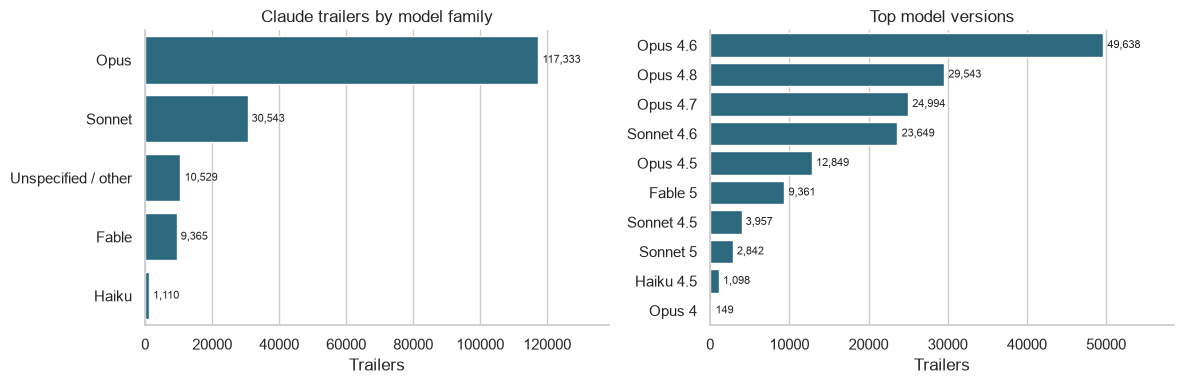

In [31]:
m = pd.DataFrame(models.items(), columns=["trailer", "n"])
m["family"]   = m.trailer.str.extract(r"(Opus|Sonnet|Haiku|Fable)", flags=re.I)[0].str.title().fillna("Unspecified / other")
m["version"]  = m.trailer.str.extract(r"(?:Opus|Sonnet|Haiku|Fable)\s*(\d(?:\.\d)?)", flags=re.I)[0]
m["long_ctx"] = m.trailer.str.contains("1M", case=False)
fam = m.groupby("family", as_index=False).n.sum().sort_values("n", ascending=False)
ver = (m.dropna(subset=["version"]).assign(label=lambda d: d.family + " " + d.version)
         .groupby("label", as_index=False).n.sum().sort_values("n", ascending=False).head(10))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
hbar(fam, "family", "n", axes[0]); axes[0].set_title("Claude trailers by model family"); axes[0].set_xlabel("Trailers")
hbar(ver, "label", "n", axes[1]);  axes[1].set_title("Top model versions");            axes[1].set_xlabel("Trailers")
plt.tight_layout()
plt.show()

## Claude models named in trailers

Claude Code trailers usually name the model, which shows what skill authors
used. Opus dominates (70% of parsed trailers, led by Opus 4.6 with 19,782
skills), followed by Sonnet (18%), Fable 5 (6%) and Haiku (<1%). About 35%
name a 1M-context variant. The versions track releases over the collection
window, from Opus 4.5 to 4.8 and Sonnet 5, so trailers also date AI
involvement. A long tail shows Claude Code run through cloud platforms (AWS
Bedrock, Databricks model IDs) and with non-Anthropic models behind it
(e.g. `Claude (glm-4.7)`, `Claude Code (Kimi)`).

In [32]:
revision_activity = con.execute(f"""
    SELECT CASE WHEN commit_count = 1 THEN '1' WHEN commit_count <= 3 THEN '2-3'
            WHEN commit_count <= 10 THEN '4-10' ELSE '>10' END AS commits,
       COUNT(*) AS skills
    FROM artifacts WHERE dedup_primary = 1 AND history_fetched = 1
    GROUP BY commits ORDER BY MIN(commit_count)
    """).df()
revision_activity

,commits,skills
0,1,303883
1,2-3,98574
2,4-10,45917
3,>10,9763


## Revision activity

Most skills are never revised: 66.3% (303,883 of 458,137) have a single commit.
Of the rest, 21.5% have 2–3 commits, 10.0% have 4–10, and only 2.1% (9,763)
have more than 10. So about a third of skills (154,254) were edited at least
once after being added, and sustained maintenance is rare. Two cautions: the
format is young (most skills were first committed in 2026), so low counts
partly reflect little elapsed time; and history follows the file's current
path, so moved or renamed skills may lose earlier commits. For authorship
analysis, revision patterns can only be computed for the revised third.

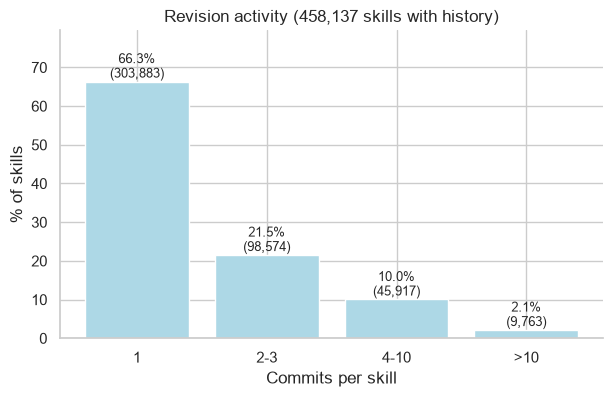

In [33]:
revision_activity["pct"] = 100 * revision_activity.skills / revision_activity.skills.sum()
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(revision_activity.commits, revision_activity.pct, color="lightblue")
ax.bar_label(bars, labels=[f"{p:.1f}%\n({s:,})" for p, s in zip(revision_activity.pct, revision_activity.skills)], fontsize=9)
ax.set_xlabel("Commits per skill"); ax.set_ylabel("% of skills")
ax.set_ylim(0, revision_activity.pct.max() * 1.2)
ax.set_title(f"Revision activity ({revision_activity.skills.sum():,} skills with history)")
plt.show()

## Revisions, bulk commits, and install messages

Among representatives with fetched history: whether a revised skill keeps the same author, whether a Claude co-author trailer appears, how often several skills land in one commit, and the messages used to install or sync them.

In [34]:
revisions = con.execute(f"""
SELECT SUM(first_commit_author = last_commit_author)  AS same_author,
       SUM(first_commit_author <> last_commit_author) AS different_author,
       SUM(lower(first_commit_message) LIKE '%co-authored-by:%claude%') AS first_claude,
       SUM(lower(last_commit_message)  LIKE '%co-authored-by:%claude%') AS last_claude,
       COUNT(*) AS revised_skills
FROM read_parquet('{artifacts_path}')
WHERE dedup_primary = 1 AND history_fetched = 1 AND commit_count > 1
""").df()
totals = revisions.iloc[0]
percentages = (totals / totals["revised_skills"] * 100).round(2)
percentages
revisions.loc["pct"] = percentages
# revisions["pct"].astype(int)
# revisions
revisions = revisions.T.rename(columns={0: "value"})
revisions["value"] = revisions["value"].astype(int)
revisions


,value,pct
same_author,132091,85.63
different_author,22163,14.37
first_claude,50761,32.91
last_claude,52769,34.21
revised_skills,154254,100.00


Of the 154,254 skills revised at least once, 85.6% (132,091) have the same
author at first and last commit; only 14.4% (22,163) change hands. Revision is
mostly the original author maintaining their own skill, not collaboration.
Claude trailers are slightly more common at the last commit (34.2%, 52,769)
than at the first (32.9%, 50,761), a net gain of about 2,000 skills, which
suggests AI tools are used for later edits at least as much as for initial
writing. These are aggregate counts, not transitions: the query does not show
how many skills gained or lost a trailer between first and last commit, and
intermediate commits are not visible.

#### Trailer transitions between first and last commit (revised skills)

In [35]:
transitions = con.execute(f"""
SELECT CASE WHEN f AND l THEN 'AI-assisted throughout' WHEN NOT f AND l THEN 'gained trailer'
            WHEN f AND NOT l THEN 'lost trailer' ELSE 'never' END AS pattern,
       COUNT(*) AS skills, ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
FROM (SELECT lower(first_commit_message) LIKE '%co-authored-by:%claude%' AS f,
             lower(last_commit_message)  LIKE '%co-authored-by:%claude%' AS l
      FROM artifacts
      WHERE dedup_primary = 1 AND history_fetched = 1 AND commit_count > 1)
GROUP BY 1 ORDER BY skills DESC
""").df()
transitions

,pattern,skills,pct
0,never,86815,56.3
1,AI-assisted throughout,36091,23.4
2,gained trailer,16678,10.8
3,lost trailer,14670,9.5


## Bulk commits
When a user commits skill files, theu add several skill files at once and commit.

In [36]:
bulk = con.execute(f"""
SELECT COUNT(*) AS bulk_commits, SUM(n) AS skills_in_bulk_commits
FROM (SELECT repo_full_name, first_commit_at, COUNT(*) AS n
      FROM artifacts
      WHERE dedup_primary = 1 AND history_fetched = 1
      GROUP BY 1, 2
      HAVING n > 1)
""").df()
bulk.T.rename(columns={0: "value"}).astype(int)

,value
bulk_commits,54362
skills_in_bulk_commits,326343


54,362 commits have been added as bulk commits. 

In [37]:
bulk = con.execute(f"""
select count(*) as repos, sum(n) as skills_in_bulk_commits from (
select repo_full_name, sum(n) as n from
(SELECT repo_full_name, first_commit_at, count(*) as n
      FROM artifacts
      WHERE dedup_primary = 1 AND history_fetched = 1 
      group by 1, 2
      having n > 1)
group by repo_full_name) 
""").df()
bulk.T.rename(columns={0: "value"}).astype(int)

,value
repos,42437
skills_in_bulk_commits,326343


42,437 repos have bulk commits for skills

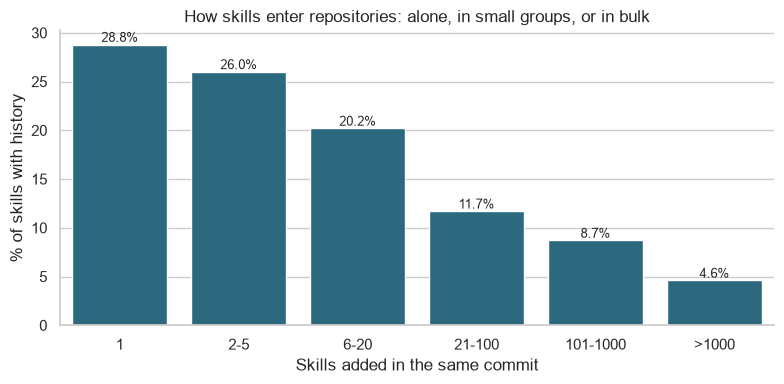

,batch_size,sort_key,commits,skills,pct_skills
0,1,1,131794,131794.0,28.8
1,2-5,2,42833,118975.0,26.0
2,6-20,6,9931,92494.0,20.2
3,21-100,21,1431,53792.0,11.7
4,101-1000,102,155,40029.0,8.7
5,>1000,1047,12,21053.0,4.6


In [38]:
batches = con.execute(f"""
WITH b AS (
  SELECT repo_full_name, first_commit_at, COUNT(*) AS n
  FROM artifacts
  WHERE dedup_primary = 1 AND history_fetched = 1
  GROUP BY 1, 2
)
SELECT CASE WHEN n = 1 THEN '1' WHEN n <= 5 THEN '2-5' WHEN n <= 20 THEN '6-20'
            WHEN n <= 100 THEN '21-100' WHEN n <= 1000 THEN '101-1000' ELSE '>1000' END AS batch_size,
       MIN(n) AS sort_key, COUNT(*) AS commits, SUM(n) AS skills,
       ROUND(100.0 * SUM(n) / SUM(SUM(n)) OVER (), 1) AS pct_skills
FROM b GROUP BY 1 ORDER BY sort_key
""").df()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=batches, x="batch_size", y="pct_skills", color=ACCENT, order=list(batches.batch_size), ax=ax)
ax.bar_label(ax.containers[0], labels=[f"{p:.1f}%" for p in batches.pct_skills], fontsize=9)
ax.set_xlabel("Skills added in the same commit"); ax.set_ylabel("% of skills with history")
ax.set_title("How skills enter repositories: alone, in small groups, or in bulk")
plt.tight_layout(); plt.show()
batches

In [39]:
install_msgs = con.execute(f"""
SELECT substr(first_commit_message, 1, 90) AS message, COUNT(*) AS skills
FROM artifacts
WHERE dedup_primary = 1 AND history_fetched = 1
  AND (lower(first_commit_message) LIKE '%install%skills%'
    OR lower(first_commit_message) LIKE '%sync%skills%'
    OR lower(first_commit_message) LIKE '%import%skills%')
GROUP BY message
ORDER BY skills DESC
LIMIT 15
""").df()
install_msgs

,message,skills
0,"Install antigravity-awesome-skills (1,465 skil...",1131
1,chore(.claude): resync .claude/ from core/ via...,1047
2,"feat: install 1016 skills from claude-forge, o...",806
3,"feat: export 5,338 skills as public SKILL.md f...",536
4,Release v215.0.0: Generische Kurz-Praefixe aus...,502
5,Add local skills and agents from community ski...,404
6,feat(plugins): per-technique plugin packs (lig...,278
7,feat: harvest 2833 legal skills from skillsmp ...,221
8,Initial release: depersonalised Claude Code co...,216
9,feat: install antigravity-awesome-skills (1300...,172


### Why bulk additions matter for authorship

A commit records who added a file to a repository, when, and with what tool.
For a skill written in place, that is close to authorship: the person who
wrote it commits it, and an AI co-author trailer reflects how it was written.
For a skill added in bulk, the same fields describe a different event. The
commit author is whoever ran the install, the message describes the batch
("install 1016 skills…") rather than the skill, and an AI trailer means only
that the install was run through an AI tool. If a developer asks Claude Code to
copy a 1,000-skill collection into a project, all 1,000 skills receive a Claude
trailer, although Claude wrote none of them. Treating these trailers as
authorship evidence would inflate the "AI-assisted" count with skills whose
origin is unknown.

We therefore exclude large batches from commit-based authorship labels. The
cutoff is chosen from the batch-size distribution: small batches (a few skills)
are consistent with one author committing related work and are kept, while
large ones are treated as installs. Excluded skills are not discarded; they
keep their text and repository features and fall into the "insufficient
evidence" category for commit-based signals.

Both detection checks undercount. Commit history exists only for each skill's
representative file, the one copy chosen during deduplication. When a
collection is installed, most of its skills already exist elsewhere, so their
representatives, and therefore their histories, sit in other repositories.
The installing repository holds only copies without history, and the install
is invisible to the timestamp check. It is detected only when the installing
repository happens to hold the representatives, typically for rare or unique
skills. Message matching misses installs committed with generic messages such
as "update" or "add files". The true share of skills added in bulk is
therefore higher than measured, and commit metadata more often describes
distribution than writing.

## Authorship label, with bulk installs excluded

The cutoff argued above is applied here. A batch is the set of representative skills (`dedup_primary = 1`) that share a repository and a `first_commit_at`. Batches of 1–5 stay eligible for a commit-based label: that is one skill committed alone, or a few committed together. Batches of 6 or more are installs. A trailer or a bot author on those commits records who ran the install, not who wrote the skill, so those skills are not labeled agent-assisted or likely human.

CI, release, distribution, and other project bots are treated the same way. Only a coding-agent bot is an agent-authorship signal. The groups are the ones from the bot-author section.

Each distinct skill receives one primary label. The first matching rule wins:

1. **highly_templated** — the same `file_sha` occurs in 10 or more files. This is a property of the text, so a bulk install does not remove it. Ten copies is the concentration point already used for reuse: skills above it are a small share of contents and a large share of files.
2. **agent_assisted** — history was fetched, the batch has fewer than 6 skills, the first author is not a non-coding bot, and either a coding agent authored the first commit or that commit names an AI tool in a `Co-authored-by` trailer (Claude, Anthropic, Cursor, Copilot, Codex, OpenAI, or Gemini).
3. **likely_human** — history was fetched, the skill was committed alone, the first author is a `User`, neither the first nor the last commit has an AI trailer, and the text occurs in exactly one file.
4. **insufficient_evidence** — no history, a bulk install that is not already a widely copied text, a non-coding bot, a batch of 2–5 with no agent signal, an organization or unlinked author, or a copy count from 2 to 9.

A missing trailer is not a human label. A skill can match more than one signal before this priority rule. The overlap table is that check: a widely copied text can also carry an AI trailer, and the rule counts it as highly templated, because the trailer may belong to the install rather than to the writing.


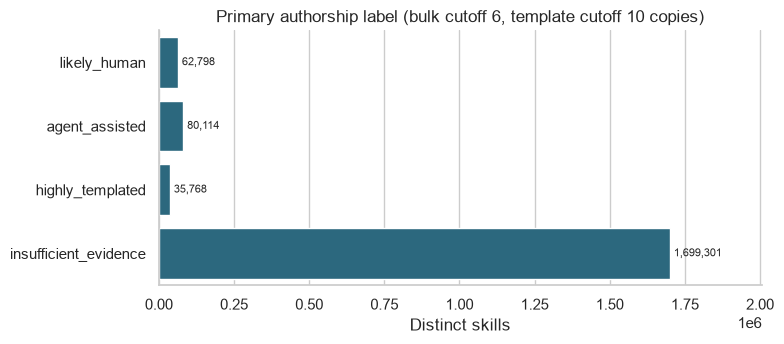

,label,skills,pct
2,likely_human,62798,3.3
0,agent_assisted,80114,4.3
1,highly_templated,35768,1.9
3,insufficient_evidence,1699301,90.5


In [40]:
BULK_MIN = 6       # representative skills sharing a repo and first_commit_at
TEMPLATE_MIN = 10  # file occurrences of one file_sha

# Same bot groups as the bot-author section.
AGENTS  = r"copilot|devin|jules|opencode|^claude|lovable|kilo-code|codex|factory-droid|amazon-q|codegen|capy-ai|warp-dev|cursor"
DISTRIB = r"clawdhub|txtskills|skill"

def _trailer(column):
    needles = ("claude", "anthropic", "cursor", "copilot", "codex", "openai", "gemini")
    return " OR ".join(
        f"lower(coalesce({column}, '')) LIKE '%co-authored-by:%{name}%'" for name in needles
    )

con.execute(f"""
CREATE OR REPLACE TEMP TABLE skill_label AS
WITH copies AS (
  SELECT file_sha, COUNT(*) AS copy_files
  FROM read_parquet('{artifacts_path}')
  GROUP BY 1
),
batch AS (
  SELECT repo_full_name, first_commit_at, COUNT(*) AS batch_n
  FROM read_parquet('{artifacts_path}')
  WHERE dedup_primary = 1 AND history_fetched = 1
  GROUP BY 1, 2
),
s AS (
  SELECT a.file_sha,
         a.history_fetched = 1 AS has_history,
         a.first_commit_author_type,
         coalesce(b.batch_n, 0) AS batch_n,
         c.copy_files,
         a.body_chars,
         (a.has_scripts = 1) AS has_scripts,
         (a.frontmatter_valid = 1) AS frontmatter_valid,
         a.commit_count,
         CASE
           WHEN coalesce(a.first_commit_author_type, '') NOT IN ('Bot', 'ProgrammaticAccessBot')
             THEN 'not a bot'
           WHEN lower(coalesce(a.first_commit_author, '')) IN ('github-actions[bot]', 'dependabot[bot]', 'renovate[bot]')
             OR lower(coalesce(a.first_commit_author, '')) LIKE '%release%'
             OR lower(coalesce(a.first_commit_author, '')) LIKE '%sync%'
             THEN 'CI, release and sync'
           WHEN regexp_matches(lower(coalesce(a.first_commit_author, '')), '{AGENTS}')
             THEN 'Coding agents'
           WHEN regexp_matches(lower(coalesce(a.first_commit_author, '')), '{DISTRIB}')
             THEN 'Skill distribution'
           ELSE 'Other project bots'
         END AS bot_group,
         ({_trailer('a.first_commit_message')}) AS ai_first,
         ({_trailer('a.last_commit_message')}) AS ai_last
  FROM read_parquet('{artifacts_path}') a
  LEFT JOIN batch b
    ON b.repo_full_name = a.repo_full_name
   AND b.first_commit_at = a.first_commit_at
  JOIN copies c ON c.file_sha = a.file_sha
  WHERE a.dedup_primary = 1
),
flagged AS (
  SELECT *,
         (has_history AND batch_n >= {BULK_MIN}) AS bulk_install,
         (copy_files >= {TEMPLATE_MIN}) AS templated_signal,
         (has_history
          AND batch_n < {BULK_MIN}
          AND bot_group NOT IN ('CI, release and sync', 'Skill distribution', 'Other project bots')
          AND (bot_group = 'Coding agents' OR ai_first)) AS agent_signal,
         (has_history
          AND batch_n = 1
          AND first_commit_author_type = 'User'
          AND NOT ai_first
          AND NOT ai_last
          AND copy_files = 1
          AND bot_group = 'not a bot') AS human_signal
  FROM s
)
SELECT *,
       CASE
         WHEN templated_signal THEN 'highly_templated'
         WHEN agent_signal     THEN 'agent_assisted'
         WHEN human_signal     THEN 'likely_human'
         ELSE 'insufficient_evidence'
       END AS label
FROM flagged
""")

label_counts = con.execute("""
SELECT label, COUNT(*) AS skills,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
FROM skill_label
GROUP BY 1
""").df()
order = ["likely_human", "agent_assisted", "highly_templated", "insufficient_evidence"]
label_counts["label"] = pd.Categorical(label_counts.label, order, ordered=True)
label_counts = label_counts.sort_values("label").assign(label=lambda d: d.label.astype(str))

fig, ax = plt.subplots(figsize=(8, 3.6))
hbar(label_counts, "label", "skills", ax)
ax.set_xlabel("Distinct skills")
ax.set_title(f"Primary authorship label (bulk cutoff {BULK_MIN}, template cutoff {TEMPLATE_MIN} copies)")
plt.tight_layout(); plt.show()
label_counts


In [41]:
NONCODING = "('CI, release and sync', 'Skill distribution', 'Other project bots')"

overlap = con.execute("""
SELECT COUNT(*) FILTER (WHERE templated_signal AND agent_signal) AS templated_and_agent_signal,
       COUNT(*) FILTER (WHERE templated_signal AND ai_first)     AS templated_and_ai_trailer,
       COUNT(*) FILTER (WHERE bulk_install AND ai_first)         AS bulk_and_ai_trailer,
       COUNT(*) FILTER (WHERE agent_signal AND human_signal)     AS agent_and_human_signal
FROM skill_label
""").df()

# Where a first-commit AI trailer lands after the priority rule.
disposition = con.execute(f"""
SELECT CASE
         WHEN templated_signal THEN 'highly_templated (copies win over the trailer)'
         WHEN bulk_install THEN 'insufficient_evidence (bulk install)'
         WHEN bot_group IN {NONCODING} THEN 'insufficient_evidence (non-coding bot)'
         ELSE 'agent_assisted (trailer kept)'
       END AS trailer_outcome,
       COUNT(*) AS skills,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
FROM skill_label
WHERE has_history AND ai_first
GROUP BY 1
ORDER BY skills DESC
""").df()

# Agent-assisted count with the batch cutoff moved or removed.
# Templated skills stay out, matching the primary label.
sensitivity = con.execute(f"""
SELECT
  COUNT(*) FILTER (
    WHERE NOT templated_signal AND agent_signal
  ) AS "applied: batch < 6",
  COUNT(*) FILTER (
    WHERE NOT templated_signal AND has_history AND batch_n < 21
      AND bot_group NOT IN {NONCODING}
      AND (bot_group = 'Coding agents' OR ai_first)
  ) AS "alternate: batch < 21",
  COUNT(*) FILTER (
    WHERE NOT templated_signal AND has_history
      AND bot_group NOT IN {NONCODING}
      AND (bot_group = 'Coding agents' OR ai_first)
  ) AS "no bulk exclusion"
FROM skill_label
""").df().T.rename(columns={0: "agent_assisted"})
sensitivity.index.name = "rule"

from IPython.display import display
display(overlap.T.rename(columns={0: "skills"}))
display(disposition)
kept = int(disposition.loc[disposition.trailer_outcome.str.startswith("agent_assisted"), "skills"].sum())
bulk_n = int(disposition.loc[disposition.trailer_outcome.str.contains("bulk install"), "skills"].sum())
trailer_n = int(disposition.skills.sum())
print(
    f"Of {trailer_n:,} skills whose first commit names an AI tool, {kept:,} stay agent-assisted. "
    f"{bulk_n:,} sit in a batch of {BULK_MIN} or more and are not labeled agent-assisted."
)
sensitivity


,skills
templated_and_agent_signal,933
templated_and_ai_trailer,5242
bulk_and_ai_trailer,58020
agent_and_human_signal,0


,trailer_outcome,skills,pct
0,agent_assisted (trailer kept),79607,57.4
1,insufficient_evidence (bulk install),53705,38.7
2,highly_templated (copies win over the trailer),5242,3.8
3,insufficient_evidence (non-coding bot),116,0.1


Of 138,670 skills whose first commit names an AI tool, 79,607 stay agent-assisted. 53,705 sit in a batch of 6 or more and are not labeled agent-assisted.


,agent_assisted
rule,
applied: batch < 6,80114
alternate: batch < 21,109423
no bulk exclusion,134028


In [42]:
label_content = con.execute("""
SELECT label,
       COUNT(*) AS skills,
       ROUND(100.0 * AVG(has_history::INT), 1) AS pct_with_history,
       CAST(AVG(body_chars) AS INT) AS avg_body_chars,
       ROUND(100.0 * AVG(has_scripts::INT), 1) AS pct_with_scripts,
       ROUND(100.0 * AVG(frontmatter_valid::INT), 1) AS pct_valid_frontmatter,
       ROUND(AVG(CASE WHEN has_history THEN commit_count END), 2) AS avg_commits_when_history
FROM skill_label
GROUP BY 1
""").df()
order = ["likely_human", "agent_assisted", "highly_templated", "insufficient_evidence"]
label_content["label"] = pd.Categorical(label_content.label, order, ordered=True)
label_content = label_content.sort_values("label").assign(label=lambda d: d.label.astype(str))
label_content


,label,skills,pct_with_history,avg_body_chars,pct_with_scripts,pct_valid_frontmatter,avg_commits_when_history
3,likely_human,62798,100.0,6095,12.7,89.4,2.69
0,agent_assisted,80114,100.0,6619,9.1,89.3,2.68
2,highly_templated,35768,59.7,8347,15.4,95.6,1.16
1,insufficient_evidence,1699301,17.3,6977,11.4,86.1,2.08


## What the label assigns

On all 1,877,981 distinct skills the primary label is:

| Label | Skills | Share |
|---|---:|---:|
| Likely human | 62,798 | 3.3% |
| Agent-assisted | 80,114 | 4.3% |
| Highly templated | 35,768 | 1.9% |
| Insufficient evidence | 1,699,301 | 90.5% |

The large insufficient-evidence share is the coverage limit, not a fourth kind of author. Commit history exists for about a quarter of distinct skills, and a missing trailer is not treated as human. Likely-human and agent-assisted are entirely history-backed, by the rules above.

**The bulk cutoff is doing the work the earlier sections only described.** With batches of 6 or more excluded, 80,114 skills are agent-assisted. Moving the cutoff to 21 raises that to 109,423. Leaving bulk installs in raises it to 134,028. Of the 138,670 skills whose first commit names an AI tool, 79,607 (57.4%) stay agent-assisted, 53,705 (38.7%) are bulk installs and drop to insufficient evidence, 5,242 (3.8%) are already widely copied and stay highly templated, and 116 (0.1%) were committed by a non-coding bot. The overlap row `bulk_and_ai_trailer` (58,020) still counts templated skills inside large batches; the disposition table applies the priority rule, so its bulk row is the subset that is not already a widely copied text. 933 skills are both widely copied and would have qualified as agent-assisted; they are counted as templated. Agent and human signals do not overlap (0 skills).

**Coarse text features still do not separate likely human from agent-assisted.** Mean body length is 6,095 versus 6,619 characters, valid front matter is 89.4% versus 89.3%, and mean commits are 2.69 versus 2.68. Highly templated skills are the group that looks different: longer (mean 8,347 characters), more often bundled with scripts (15.4%, against 12.7% and 9.1%), more often valid front matter (95.6%), and rarely revised (mean 1.16 commits where history exists). Only 59.7% of them have history.

The month, location, and star breakdowns below still include bulk additions. They describe the raw trailer rate. This section is the view with the exclusion applied.


In [43]:
ai_share = con.execute(f"""
WITH h AS (
  SELECT a.first_commit_at, a.location_class, r.stars,
         CAST(
           lower(a.first_commit_message) LIKE '%co-authored-by:%claude%'
        OR lower(a.first_commit_message) LIKE '%co-authored-by:%anthropic%'
        OR lower(a.first_commit_message) LIKE '%co-authored-by:%cursor%'
        OR lower(a.first_commit_message) LIKE '%co-authored-by:%copilot%'
        OR lower(a.first_commit_message) LIKE '%co-authored-by:%codex%'
         AS INTEGER) AS ai
  FROM read_parquet('{artifacts_path}') a
  LEFT JOIN read_parquet('{repos_path}') r ON r.full_name = a.repo_full_name
  WHERE a.dedup_primary = 1 AND a.history_fetched = 1
)
SELECT 'month' AS dim, substr(first_commit_at, 1, 7) AS value,
       COUNT(*) AS skills, ROUND(100.0 * AVG(ai), 1) AS pct_ai
FROM h GROUP BY 2
UNION ALL
SELECT 'location', location_class, COUNT(*), ROUND(100.0 * AVG(ai), 1)
FROM h GROUP BY 2
UNION ALL
SELECT 'stars',
       CASE WHEN stars = 0 THEN '0' WHEN stars < 10 THEN '1-9'
            WHEN stars < 100 THEN '10-99' ELSE '100+' END,
       COUNT(*), ROUND(100.0 * AVG(ai), 1)
FROM h GROUP BY 2
ORDER BY 1, 2;
""").df()
ai_share

,dim,value,skills,pct_ai
0,location,canonical,272555,36.9
1,location,other,64494,23.3
2,location,skills-dir,121088,19.1
3,month,2014-06,1,0.0
4,month,2017-07,1,0.0
5,month,2017-12,1,0.0
6,month,2018-03,1,0.0
7,month,2018-05,2,0.0
8,month,2019-01,2,0.0
9,month,2019-05,1,0.0


## AI-trailer share by time, location and popularity

**Time.** Skills first committed from October 2025, when the format launched,
account for all but ~200 of the 458,137 with history; the handful dated earlier
are files that existed before becoming a `SKILL.md` (history follows the
current path) and are excluded here. Early adopters show the highest AI-trailer
share (39% in November 2025). As volume grew tenfold from February 2026, the
share settled at about 28%, then rose to 32% in June and 38% in July (a partial
month). AI involvement is substantial throughout and shows no steady decline.

**Location.** Skills in canonical agent folders (e.g. `.claude/skills/`) carry
an AI trailer far more often (36.9%) than those in generic `skills/`
directories (19.1%) or other paths (23.3%). Canonical folders are where skills
are written inside an agent project, and Claude Code adds trailers
automatically; generic folders more often hold collections and installed
skills. The gap therefore reflects both the tool used and how the file
arrived, not only how it was written.

**Popularity.** The share falls from 32.4% in 0-star repositories to 25.8% in
repositories with 10–99 stars, with a slight rise at 100+ (27.7%). Small
personal projects are more often one developer working in an agent tool, while
popular repositories have more contributors, review processes and, in some
cases, policies against AI trailers. Lower rates there do not imply less AI use.

**Caveats.** Trailers are positive-only, so all figures are lower bounds on AI
involvement. These breakdowns still include bulk additions, so a large install
run through an agent tool can shift a month or location group. The authorship
label above applies that exclusion.

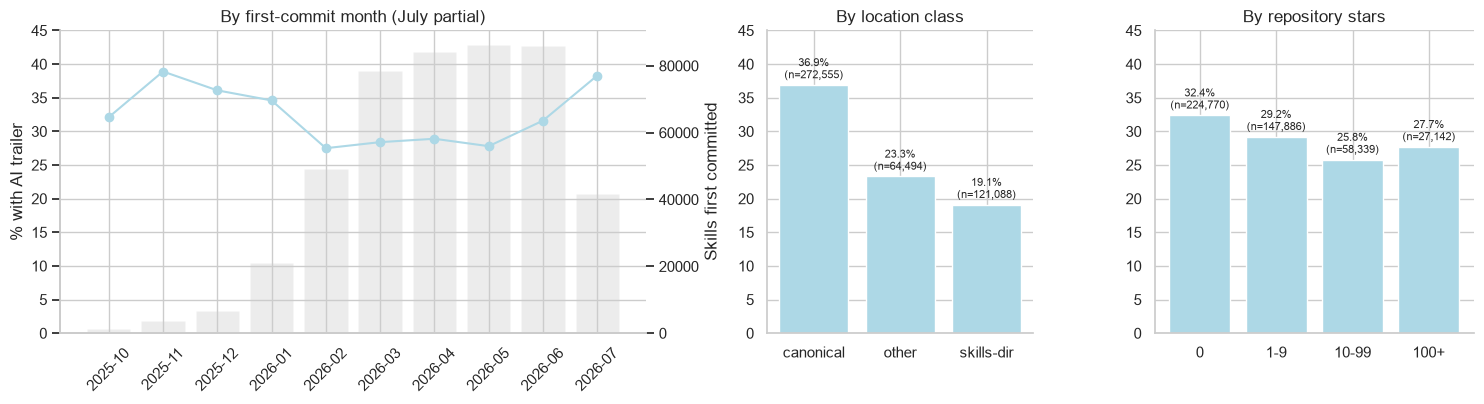

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), gridspec_kw={"width_ratios": [2.2, 1, 1.2]})

# 1. Month: format era only, drop tiny early groups
m = ai_share[(ai_share.dim == "month") & (ai_share.value >= "2025-10")].sort_values("value")
ax = axes[0]
ax.plot(m.value, m.pct_ai, marker="o", color="lightblue")
ax2 = ax.twinx()
ax2.bar(m.value, m.skills, alpha=.15, color="GREY")
ax2.set_ylabel("Skills first committed"); ax2.grid(False)
ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)
ax.set_ylim(0, 45); ax.set_ylabel("% with AI trailer")
ax.set_title("By first-commit month (July partial)")
ax.tick_params(axis="x", rotation=45)

# 2. Location class
loc = ai_share[ai_share.dim == "location"].sort_values("pct_ai", ascending=False)
axes[1].bar(loc.value, loc.pct_ai, color="lightblue")
axes[1].set_title("By location class"); axes[1].set_ylim(0, 45)

# 3. Star tier
order = ["0", "1-9", "10-99", "100+"]
st = ai_share[ai_share.dim == "stars"].set_index("value").loc[order]
axes[2].bar(st.index, st.pct_ai, color="lightblue")
axes[2].set_title("By repository stars"); axes[2].set_ylim(0, 45)

for ax, df in [(axes[1], loc), (axes[2], st.reset_index())]:
    for i, (p, n) in enumerate(zip(df.pct_ai, df.skills)):
        ax.text(i, p + 1, f"{p:.1f}%\n(n={n:,})", ha="center", fontsize=8)

plt.tight_layout(); plt.show()

In [45]:
ai_trailer_skills_content = con.execute(f"""
SELECT (lower(first_commit_message) LIKE '%co-authored-by:%claude%'
     OR lower(first_commit_message) LIKE '%co-authored-by:%cursor%'
     OR lower(first_commit_message) LIKE '%co-authored-by:%copilot%'
     OR lower(first_commit_message) LIKE '%co-authored-by:%codex%') AS ai_trailer,
       COUNT(*)                       AS skills,
       CAST(AVG(body_chars) AS INT)   AS avg_body_chars,
       ROUND(AVG(has_scripts), 3)     AS share_with_scripts,
       ROUND(AVG(frontmatter_valid), 3) AS share_valid_fm,
       ROUND(AVG(commit_count), 2)    AS avg_commits
FROM read_parquet('{artifacts_path}') WHERE dedup_primary = 1 AND history_fetched = 1
GROUP BY ai_trailer;
""").df()
ai_trailer_skills_content

,ai_trailer,skills,avg_body_chars,share_with_scripts,share_valid_fm,avg_commits
0,False,319523,6108,0.098,0.866,2.19
1,True,138614,6737,0.088,0.896,2.31


## Do AI-trailer skills look different?

Comparing skills whose first commit carries an AI trailer (138,614) with those
without (319,523), the content differs only slightly:

| | AI trailer | No trailer |
|---|---|---|
| Mean body length (chars) | 6,737 | 6,108 |
| Bundles scripts | 8.8% | 9.8% |
| Valid front matter | 89.6% | 86.6% |
| Mean commits | 2.31 | 2.19 |

AI-assisted skills are about 10% longer, more often have spec-compliant front
matter (agents reliably produce the required `name` and `description`), bundle
scripts slightly less often, and are revised marginally more. All differences
are small and the distributions overlap heavily, so these coarse features
cannot separate AI-assisted from other skills individually. Two factors narrow
the gap further: "no trailer" includes AI-assisted skills whose tool added no
trailer, and trailer skills are concentrated in canonical agent folders, so
part of the difference reflects location rather than authorship. Richer text
features may separate the groups better; on these measures, authorship signal
lives mainly in commit metadata, not in the text. This split also still includes
bulk installs. The label section above drops those batches and separates widely
copied texts before comparing length, scripts, and front matter.